# Football Player Evaluation Model - Analysis



## 0. Setup - Imports and Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import config
from src.analysis.game_utils import game_summary
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence import SequencePreprocessor, PreprocessingMode
from src.ml.xthreat import get_default_xt_model
from src.analysis.prediction_utils import get_top_indices, normalize_predictions, print_top_predictions, visualize_top_possessions, visualize_top_possessions_matches, create_top_possessions_df, create_top_possessions_df_matches


In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
all_matches = list(data)

# Sort matches by game_date
all_matches.sort(key=lambda x: x[0].get('game_date', ''), reverse=True)

len(all_matches)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

51

### 1.1 Validation Set Matches Information

In [4]:
matches_info = []

for match, events_df in all_matches:
    matches_info.append(game_summary(match))

for match in matches_info:
    print(match)


Spain 2 : 1 England (Final) [14.07.2024]
Netherlands 1 : 2 England (Semi-finals) [10.07.2024]
Spain 2 : 1 France (Semi-finals) [09.07.2024]
Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024]
England 1 : 1 Switzerland (Quarter-finals) [06.07.2024]
Portugal 0 : 0 France (Quarter-finals) [05.07.2024]
Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]
Austria 1 : 2 Turkey (Round of 16) [02.07.2024]
Romania 0 : 3 Netherlands (Round of 16) [02.07.2024]
Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024]
France 1 : 0 Belgium (Round of 16) [01.07.2024]
Spain 4 : 1 Georgia (Round of 16) [30.06.2024]
England 2 : 1 Slovakia (Round of 16) [30.06.2024]
Germany 2 : 0 Denmark (Round of 16) [29.06.2024]
Switzerland 2 : 0 Italy (Round of 16) [29.06.2024]
Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024]
Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]
Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]
Denmark 0 : 0 Serbia (Group Stage) [25.06.2024

## 2. Load Trained Model

In [5]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [6]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 46)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       179,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,154,327 (4.40 MB)

 Trainable params: 384,775 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,552 (2.94 MB)

## 3. Preprocess Data for Analysis

In [7]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p, m = preprocessor.process_matches(all_matches, mode=PreprocessingMode.VALIDATION)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: validation)
 → Generated 124 sequences, 124 labels for match 3943043
→Processing match 3942819: 3485 events (mode: validation)
 → Generated 97 sequences, 97 labels for match 3942819
→Processing match 3942752: 3328 events (mode: validation)
 → Generated 132 sequences, 132 labels for match 3942752
→Processing match 3942382: 3415 events (mode: validation)
 → Generated 105 sequences, 105 labels for match 3942382
→Processing match 3942227: 4882 events (mode: validation)
 → Generated 134 sequences, 134 labels for match 3942227
→Processing match 3942349: 5190 events (mode: validation)
 → Generated 158 sequences, 158 labels for match 3942349
→Processing match 3942226: 4463 events (mode: validation)
 → Generated 187 sequences, 187 labels for match 3942226
→Processing match 3941022: 3722 events (mode: validation)
 → Generated 146 sequences, 146 labels for match 3941022
→Processing match 3941021: 2996 events (mode: validation)
 → Generated 130 sequenc

In [8]:
X.shape

(6823, 6, 46)

In [9]:
p.shape

(6823,)

In [10]:
p[0:200]

array([  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
        16,  17,  19,  21,  22,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        46,  47,  48,  49,  50,  51,  52,  53,  54,  56,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  69,  71,  73,  74,  75,  77,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 119, 120,
       121, 122, 123, 124, 125, 127, 128, 129, 130, 131, 132, 133, 134,
       135, 136, 137, 138, 142, 144, 146,   2,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  16,  17,  18,  22,  23,  24,  25,
        26,  27,  28,  30,  31,  32,  33,  34,  36,  37,  38,  39,  40,
        41,  42,  44,  45,  46,  47,  48,  49,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  6

## 4. Analysis


#### Extract match information from all matches

In [11]:
from src.analysis.prediction_utils import matches_info_df

matches_df = matches_info_df(all_matches)
matches_df.head(10)

,match_id,summary,events_count
0,3943043,Spain 2 : 1 England (Final) [14.07.2024],3312
1,3942819,Netherlands 1 : 2 England (Semi-finals) [10.07.2024],3485
2,3942752,Spain 2 : 1 France (Semi-finals) [09.07.2024],3328
3,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415
4,3942227,England 1 : 1 Switzerland (Quarter-finals) [06.07.2024],4882
5,3942349,Portugal 0 : 0 France (Quarter-finals) [05.07.2024],5190
6,3942226,Spain 2 : 1 Germany (Quarter-finals) [05.07.2024],4463
7,3941022,Austria 1 : 2 Turkey (Round of 16) [02.07.2024],3722
8,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07.2024],2996
9,3941020,Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024],4221


#### Predictions for all matches

In [12]:
predictions = model.predict(X, batch_size=32, verbose=0)

In [13]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 6823
Sum of all predicted values: 366.248
Has attention weights: True


#### Get top 8 sequences by predicted value across all matches

In [14]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, m, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Match ID = 3930160, Possession ID = 105: Value = 1.134
   Attention weights: ['0.057', '0.061', '0.123', '0.241', '0.288', '0.229']
   Most important action: position 4 (weight: 0.288)

2. Match ID = 3930170, Possession ID = 69: Value = 0.850
   Attention weights: ['0.096', '0.099', '0.111', '0.168', '0.271', '0.255']
   Most important action: position 4 (weight: 0.271)

3. Match ID = 3938638, Possession ID = 93: Value = 0.807
   Attention weights: ['0.168', '0.156', '0.153', '0.168', '0.179', '0.177']
   Most important action: position 4 (weight: 0.179)

4. Match ID = 3930174, Possession ID = 90: Value = 0.767
   Attention weights: ['0.154', '0.150', '0.146', '0.176', '0.184', '0.190']
   Most important action: position 5 (weight: 0.190)

5. Match ID = 3942227, Possession ID = 105: Value = 0.660
   Attention weights: ['0.178', '0.144', '0.164', '0.171', '0.171', '0.171']
   Most important action: position 0 (weight: 0.178)

6. Match 

#### Prepare possessions for all matches

In [15]:
from src.analysis.prediction_utils import create_possessions_list
import gc

game_possessions_list = create_possessions_list(all_matches)
del all_matches
gc.collect()

0

#### Top possessions information

In [16]:
top_possessions_df_matches = create_top_possessions_df_matches(game_possessions_list, p, m, predicted_values, attention_weights, 80)
top_possessions_df_matches.to_csv(f"models/{MODEL_TYPE}/top_possessions_all_matches_df.csv", index=False)
top_possessions_df_matches.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,105,1.134083,"[0.05728982, 0.061140314, 0.12284962, 0.2410971, 0.28841034, 0.22921285]",3930160,785,Croatia,2,3232,3274,Shot
1,69,0.850403,"[0.09581921, 0.099115714, 0.11130728, 0.16799803, 0.27054837, 0.25521135]",3930170,944,Slovenia,1,2160,2224,Shot
2,93,0.807465,"[0.16777872, 0.1557213, 0.1530697, 0.16770427, 0.17864001, 0.1770859]",3938638,905,Romania,2,3382,3387,Goal
3,90,0.767159,"[0.15399657, 0.14964119, 0.14649108, 0.17620938, 0.18386135, 0.18980041]",3930174,780,Portugal,2,3291,3303,Goal
4,105,0.660135,"[0.178106, 0.14443295, 0.1636472, 0.1714576, 0.17129499, 0.17106129]",3942227,773,Switzerland,2,4389,4454,Goal


#### Visualize top 8 possessions from validation set on the pitch

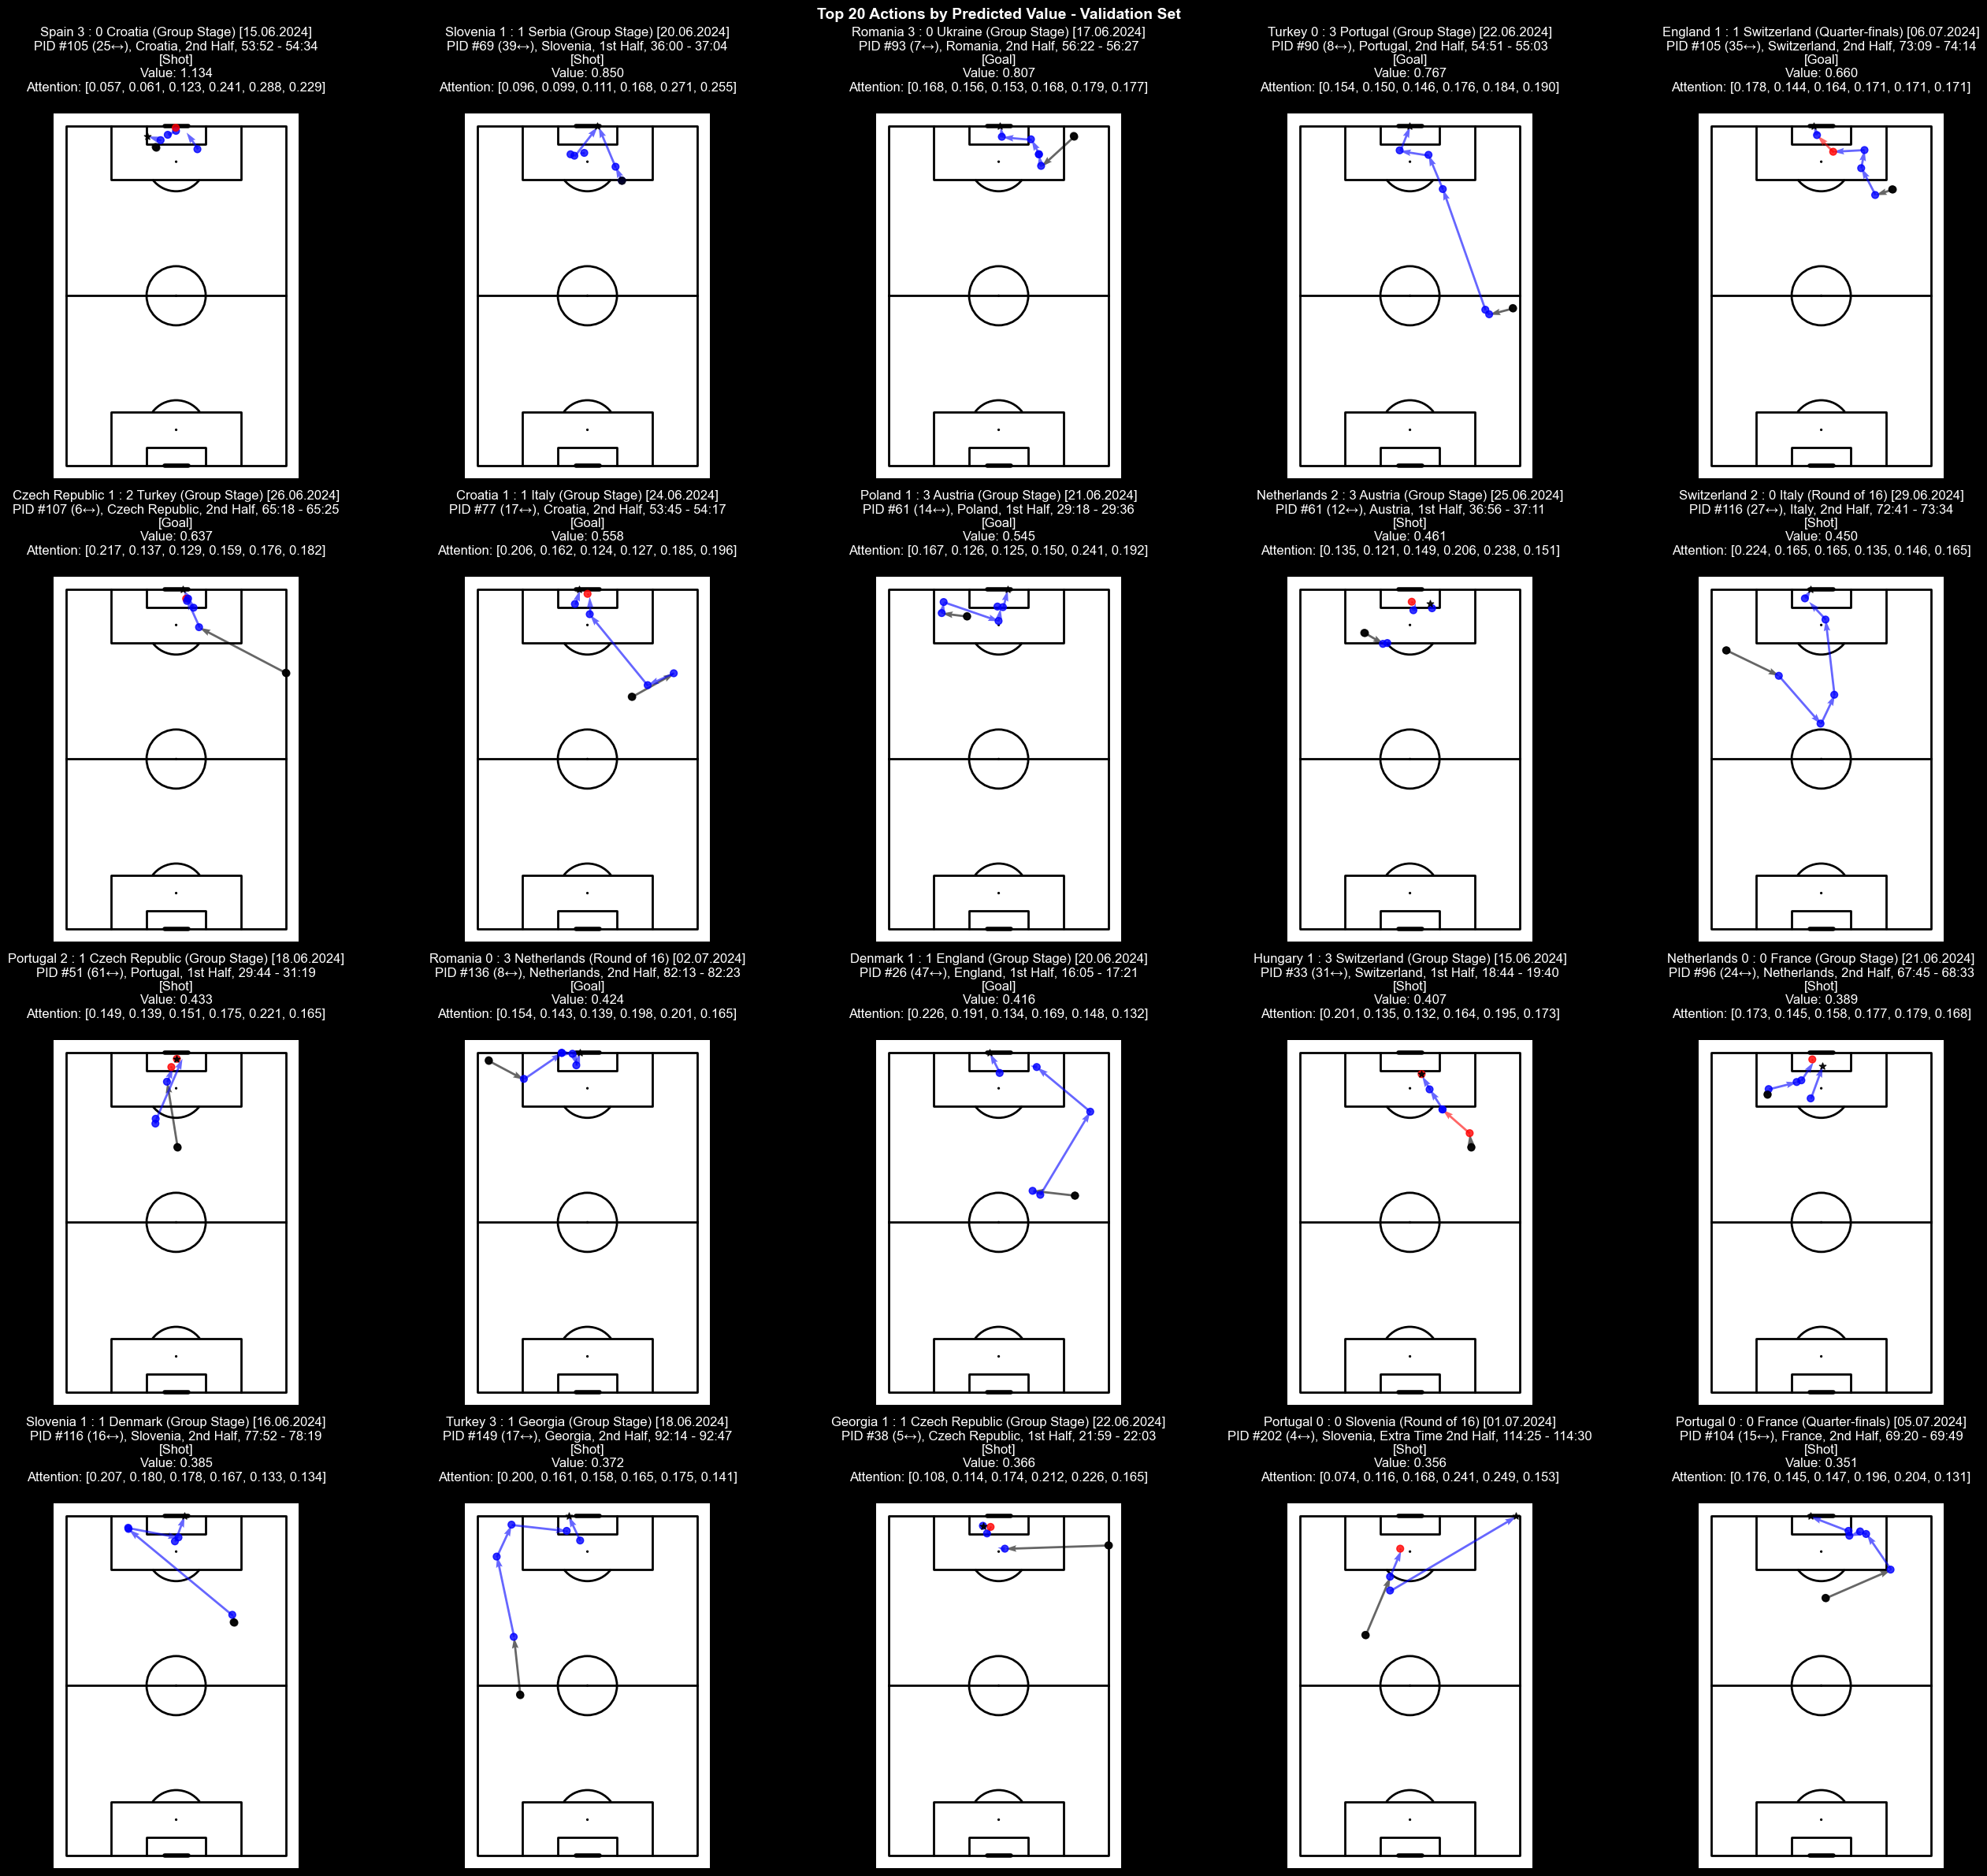

In [17]:
visualize_top_possessions_matches(game_possessions_list, p, m, predicted_values, attention_weights, 20, config.SEQUENCE_LENGTH)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_all_matches.png", dpi=300)
